# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [26]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "../../"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/shea/Research/PythonWorkspace/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.
****Shea's note:** I had to change the read_csv call because of  versioning issues. keep_date_col=false is now default and that keyword is no longer valid. the AI assistant also suggested a a different way to name the columns that should be version-invariant (since it was reading parse_dates as a list of lists which is no longer valid).

In [27]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df.iloc[:, 0].astype(str) + "-" +
                             df.iloc[:, 1].astype(str).str.zfill(2) + "-" +
                             df.iloc[:, 2].astype(str).str.zfill(2))
df.drop(columns=df.columns[:3], inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

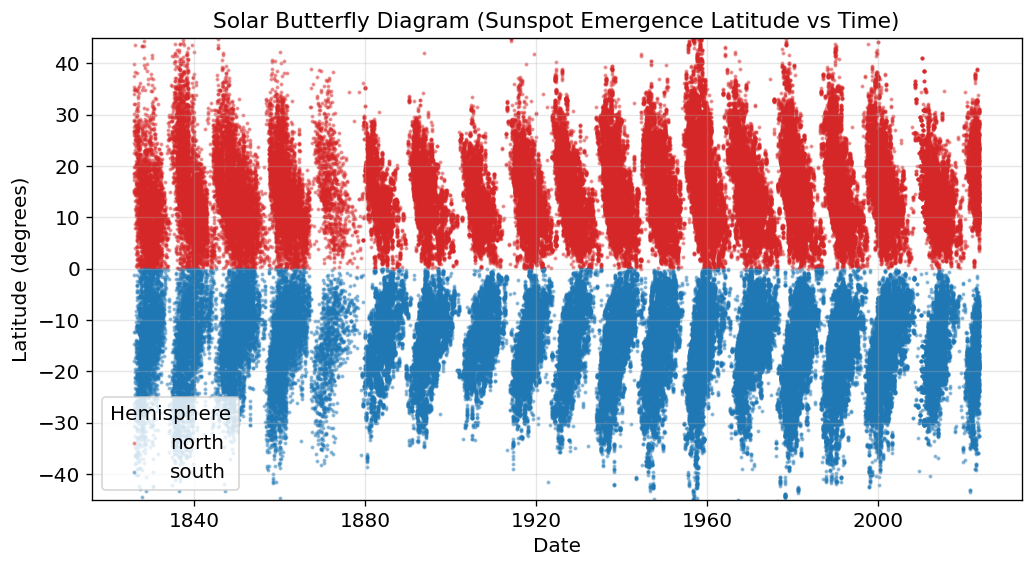

In [28]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:** 
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


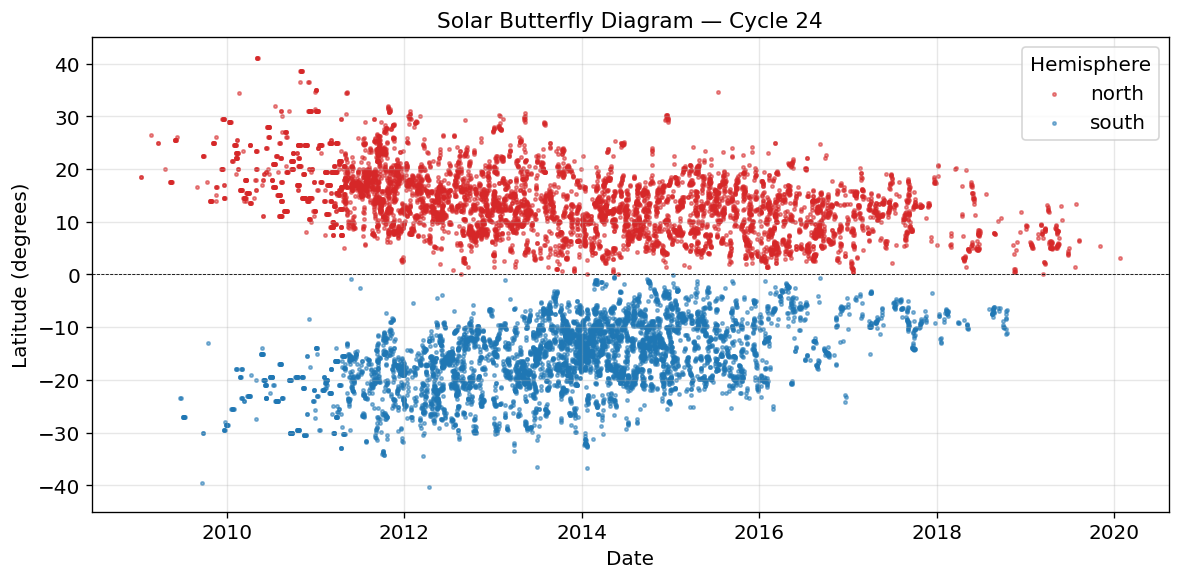

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [29]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_1013285/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


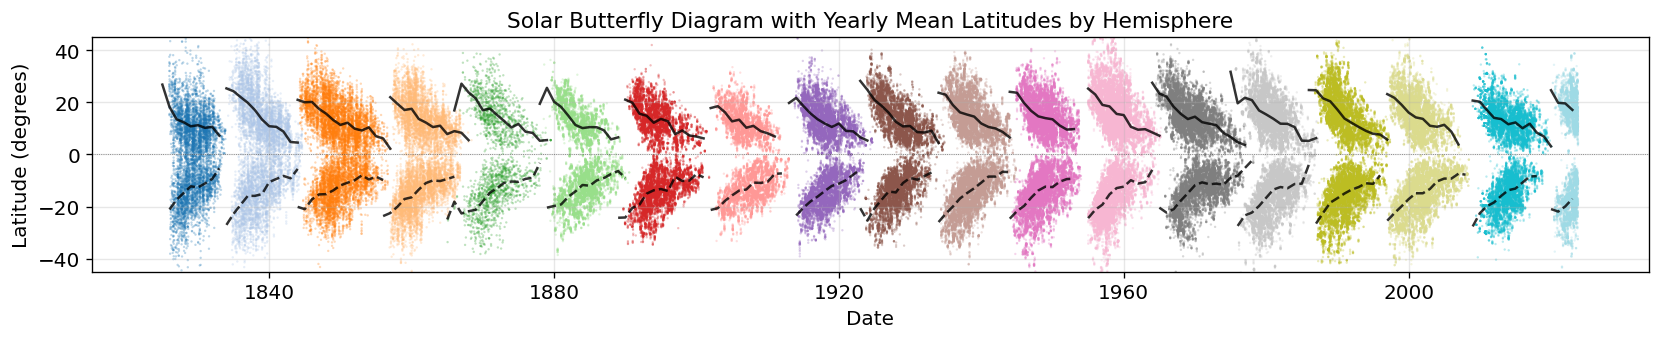

In [30]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2, 
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}", 
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]
    
    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
                linewidth=1.5, linestyle="-", alpha=0.8)
    
    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

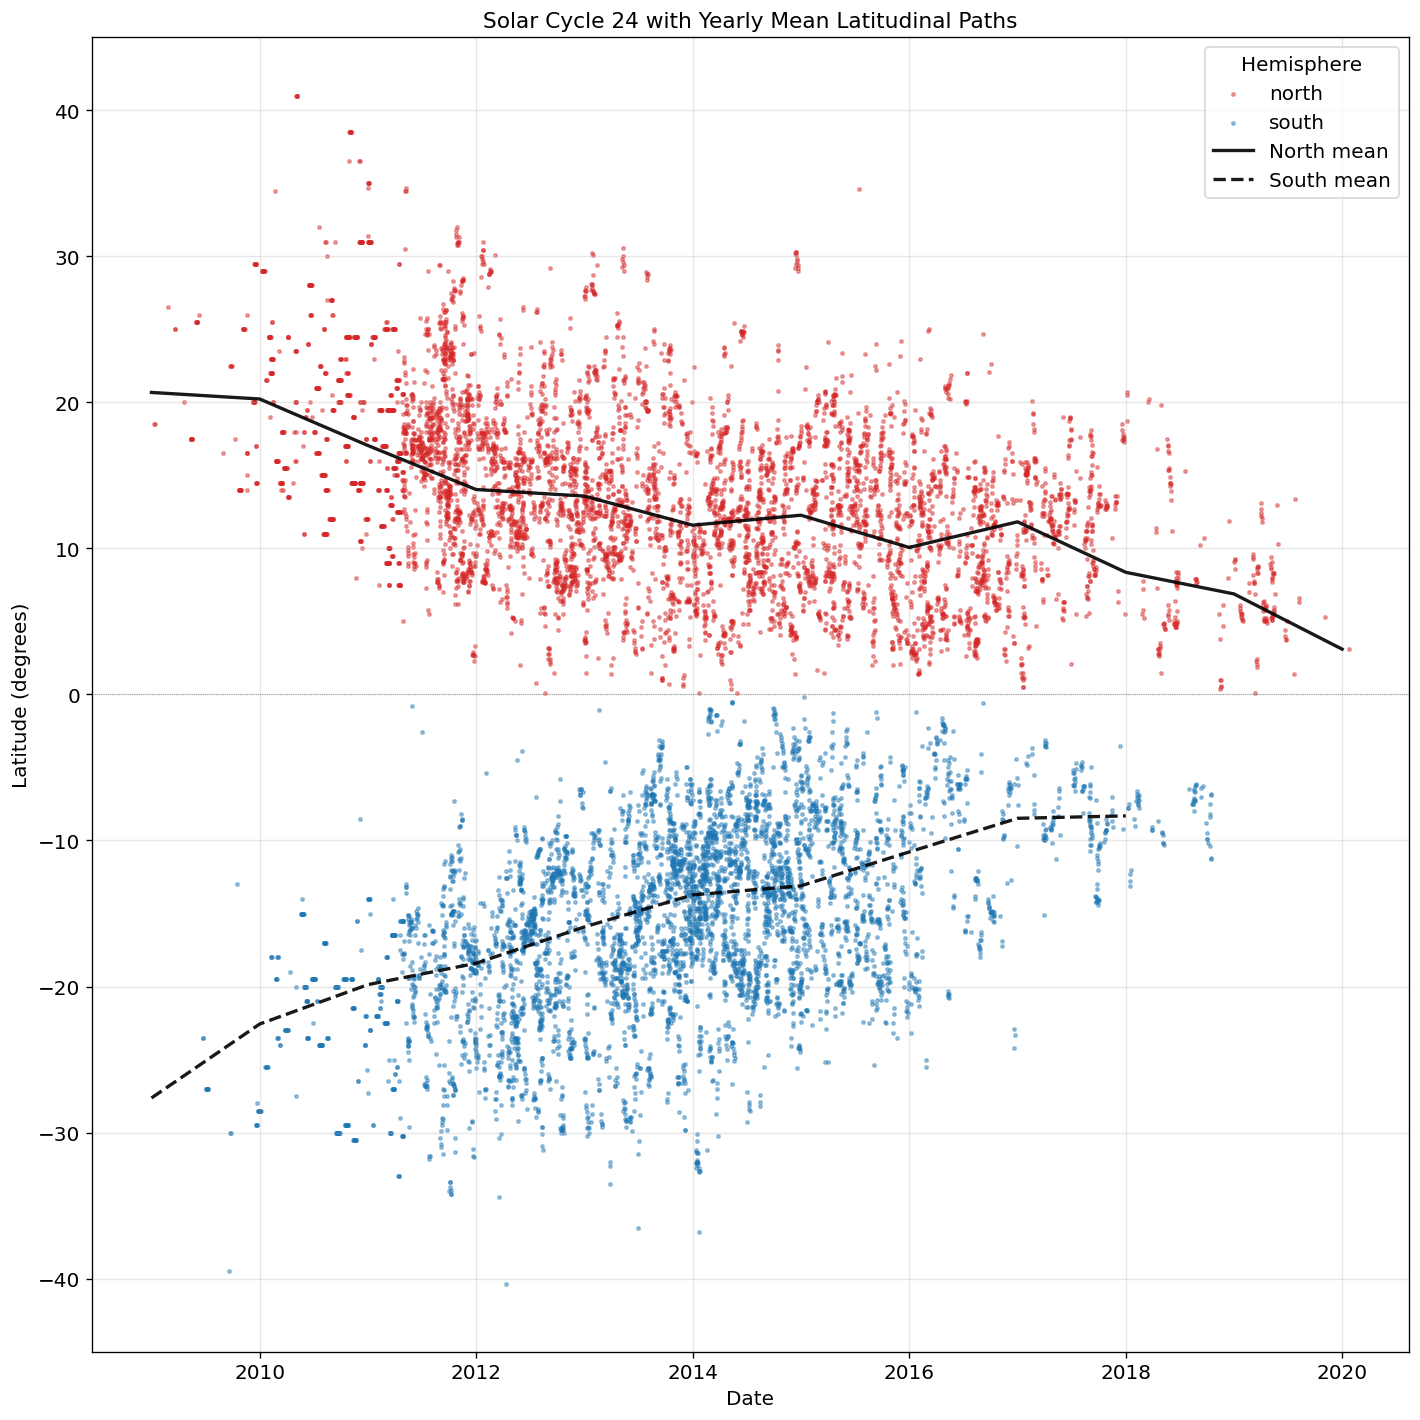

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [31]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black", 
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black", 
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


Year 1987, north hemisphere  (N = 240)
  Mean:   21.40°
  Median: 22.46°
  Mode:   29.88°  (histogram bin centre)
  Q1:     15.49°   Q3: 28.77°   IQR: 13.28°


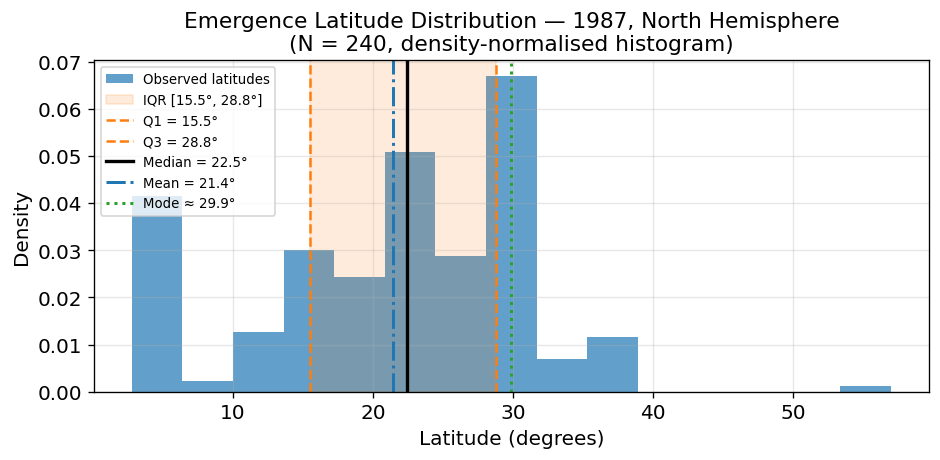

In [32]:
# Task 6: Empirical distribution of emergence latitudes for a single year/hemisphere
# Using 1987, northern hemisphere — a mid-cycle year with good coverage

year  = 1987
hemi  = "north"

mask  = (df["year"] == year) & (df["hemisphere"] == hemi)
lats  = df[mask]["latitude"].values

# Summary statistics
q1     = np.percentile(lats, 25)
median = np.median(lats)
q3     = np.percentile(lats, 75)
mean   = lats.mean()
# Mode: bin centre with highest count
n_bins = 15
counts, bin_edges = np.histogram(lats, bins=n_bins)
mode   = 0.5 * (bin_edges[counts.argmax()] + bin_edges[counts.argmax() + 1])

print(f"Year {year}, {hemi} hemisphere  (N = {len(lats)})")
print(f"  Mean:   {mean:.2f}°")
print(f"  Median: {median:.2f}°")
print(f"  Mode:   {mode:.2f}°  (histogram bin centre)")
print(f"  Q1:     {q1:.2f}°   Q3: {q3:.2f}°   IQR: {q3-q1:.2f}°")

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=n_bins, density=True, color="tab:blue", alpha=0.7, label="Observed latitudes")

# IQR shading
ax.axvspan(q1, q3, color="tab:orange", alpha=0.15, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Marker lines
ax.axvline(q1,     color="tab:orange", linewidth=1.5, linestyle="--", label=f"Q1 = {q1:.1f}°")
ax.axvline(q3,     color="tab:orange", linewidth=1.5, linestyle="--", label=f"Q3 = {q3:.1f}°")
ax.axvline(median, color="black",      linewidth=2.0, linestyle="-",  label=f"Median = {median:.1f}°")
ax.axvline(mean,   color="tab:blue",   linewidth=1.8, linestyle="-.", label=f"Mean = {mean:.1f}°")
ax.axvline(mode,   color="tab:green",  linewidth=1.8, linestyle=":",  label=f"Mode ≈ {mode:.1f}°")

ax.set_title(f"Emergence Latitude Distribution — {year}, {hemi.capitalize()} Hemisphere\n"
             f"(N = {len(lats)}, density-normalised histogram)")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Density")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


**Shea's note:** The 1987 northern hemisphere data contains a mix of two solar cycles — Cycle 22 (which was active in 1987) makes up ~83% of the observations (200/240), while a tail of late Cycle 21 activity accounts for ~9% (21/240). There is also a striking outlier at ~57°, which turns out to be a real Cycle 22 emergence from August 1987 — an unusually high-latitude active region, not a data error. This overlap between cycles means the fitted Gaussian is slightly wider than the "true" single-cycle distribution, and its mean is pulled slightly equatorward by the lower-latitude Cycle 21 remnants.


## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


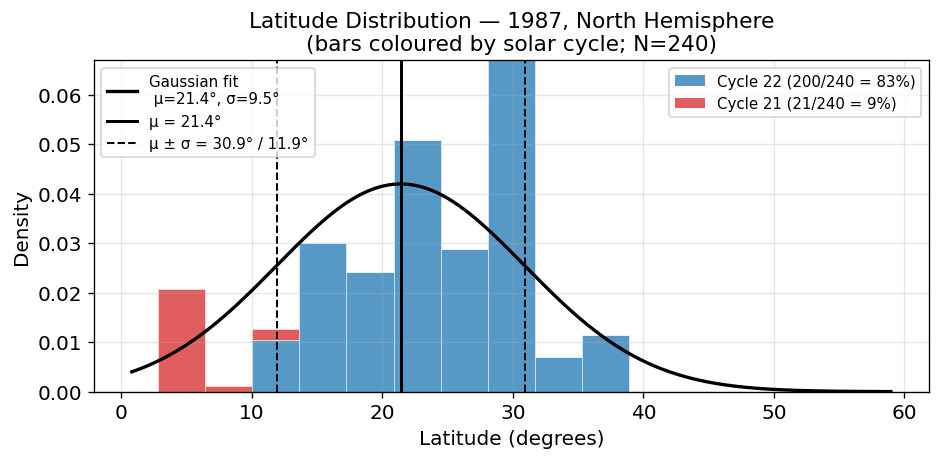

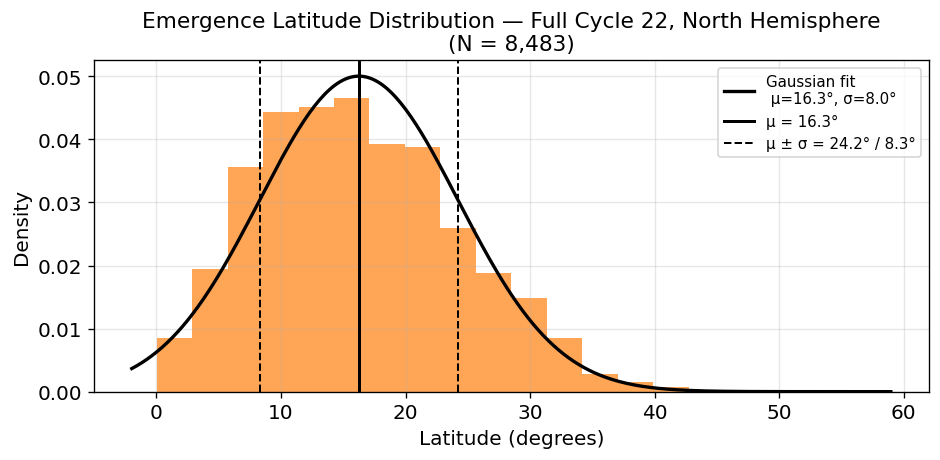

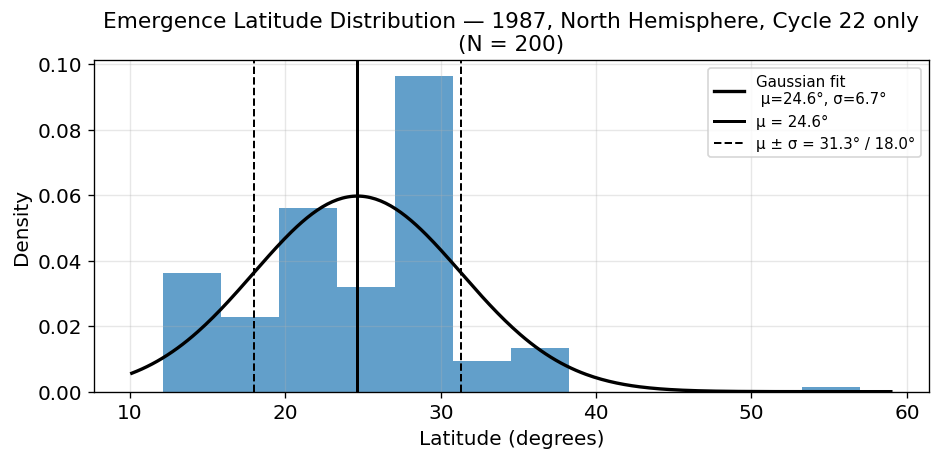


Summary for 1987 north:
  All cycles:          μ=21.40°, σ=9.51°  (N=240)
  Cycle 22 only:       μ=24.64°, σ=6.68°  (N=200)
  Cycle 22 full cycle: μ=16.25°, σ=7.97°  (N=8,483)


In [33]:

# Task 7: Fit a Gaussian to the latitude distribution
# Three plots:
#   1. 1987 north (all cycles) — stacked bars colored by cycle mix + Gaussian fit
#   2. Full Cycle 22 north hemisphere — histogram + Gaussian fit
#   3. 1987 north, Cycle 22 only    — histogram + Gaussian fit

from scipy.stats import norm
from matplotlib.patches import Patch

# ── shared setup ──────────────────────────────────────────────────────────────
year  = 1987
hemi  = "north"

mask       = (df["year"] == year) & (df["hemisphere"] == hemi)
n_c22      = int((mask & (df["CYCLE"] == 22)).sum())
n_c21      = int((mask & (df["CYCLE"] == 21)).sum())
total_obs  = int(mask.sum())
frac_c22   = n_c22 / total_obs
frac_c21   = n_c21 / total_obs

# Fit Gaussian to the full 1987-north sample
lats      = df[mask]["latitude"].values
mu, sigma = norm.fit(lats)
x         = np.linspace(lats.min() - 2, lats.max() + 2, 300)

# ── Plot 1: 1987, all cycles, stacked bars ────────────────────────────────────
n_bins     = 15
counts_total, bin_edges = np.histogram(lats, bins=n_bins)
bin_width  = bin_edges[1] - bin_edges[0]
total_area = counts_total.sum() * bin_width   # normalisation factor

fig, ax = plt.subplots(figsize=(8, 4))

# Build stacked (density) bars bin-by-bin
cycle_colors_map = {21: "tab:red", 22: "tab:blue"}
for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    in_bin      = df[mask & (df["latitude"] >= lo) & (df["latitude"] < hi)]
    n_total_bin = len(in_bin)
    bar_height  = n_total_bin / total_area          # density height

    n_c22_bin = (in_bin["CYCLE"] == 22).sum()
    n_c21_bin = (in_bin["CYCLE"] == 21).sum()
    h_c22 = (n_c22_bin / total_area)
    h_c21 = (n_c21_bin / total_area)

    ax.bar(lo, h_c22, width=bin_width, align="edge",
           color="tab:blue", alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.bar(lo, h_c21, width=bin_width, align="edge",
           bottom=h_c22,
           color="tab:red",  alpha=0.75, edgecolor="white", linewidth=0.4)

# Gaussian fit overlay
ax.plot(x, norm.pdf(x, mu, sigma), "k-", linewidth=2,
        label=f"Gaussian fit\n μ={mu:.1f}°, σ={sigma:.1f}°")

# μ and ±σ vertical lines
ax.axvline(mu,         color="black",      linewidth=1.8, linestyle="-",
           label=f"μ = {mu:.1f}°")
ax.axvline(mu + sigma, color="black",      linewidth=1.2, linestyle="--",
           label=f"μ ± σ = {mu+sigma:.1f}° / {mu-sigma:.1f}°")
ax.axvline(mu - sigma, color="black",      linewidth=1.2, linestyle="--")

# Dual legend
leg1 = ax.legend(loc="upper left", fontsize=9)
cycle_legend = [Patch(facecolor="tab:blue", alpha=0.75,
                      label=f"Cycle 22 ({n_c22}/{total_obs} = {frac_c22:.0%})"),
                Patch(facecolor="tab:red",  alpha=0.75,
                      label=f"Cycle 21 ({n_c21}/{total_obs} = {frac_c21:.0%})")]
ax.add_artist(leg1)
ax.legend(handles=cycle_legend, loc="upper right", fontsize=9)

ax.set_title(f"Latitude Distribution — {year}, {hemi.capitalize()} Hemisphere\n"
             f"(bars coloured by solar cycle; N={total_obs})")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

# ── Plot 2: Full Cycle 22, north ──────────────────────────────────────────────
mask_c22          = (df["CYCLE"] == 22) & (df["hemisphere"] == hemi)
lats_c22          = df[mask_c22]["latitude"].values
mu_c22, sigma_c22 = norm.fit(lats_c22)
x_c22             = np.linspace(lats_c22.min() - 2, lats_c22.max() + 2, 300)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(lats_c22, bins=20, density=True, color="tab:orange", alpha=0.7)
ax2.plot(x_c22, norm.pdf(x_c22, mu_c22, sigma_c22), "k-", linewidth=2,
         label=f"Gaussian fit\n μ={mu_c22:.1f}°, σ={sigma_c22:.1f}°")

# μ and ±σ vertical lines
ax2.axvline(mu_c22,               color="black", linewidth=1.8, linestyle="-",
            label=f"μ = {mu_c22:.1f}°")
ax2.axvline(mu_c22 + sigma_c22,   color="black", linewidth=1.2, linestyle="--",
            label=f"μ ± σ = {mu_c22+sigma_c22:.1f}° / {mu_c22-sigma_c22:.1f}°")
ax2.axvline(mu_c22 - sigma_c22,   color="black", linewidth=1.2, linestyle="--")

ax2.set_title(f"Emergence Latitude Distribution — Full Cycle 22, {hemi.capitalize()} Hemisphere\n"
              f"(N = {len(lats_c22):,})")
ax2.set_xlabel("Latitude (degrees)")
ax2.set_ylabel("Density")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 3: 1987, Cycle 22 only ───────────────────────────────────────────────
mask_1987_c22               = mask & (df["CYCLE"] == 22)
lats_1987_c22               = df[mask_1987_c22]["latitude"].values
mu_1987_c22, sigma_1987_c22 = norm.fit(lats_1987_c22)
x3 = np.linspace(lats_1987_c22.min() - 2, lats_1987_c22.max() + 2, 300)

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(lats_1987_c22, bins=12, density=True, color="tab:blue", alpha=0.7)
ax3.plot(x3, norm.pdf(x3, mu_1987_c22, sigma_1987_c22), "k-", linewidth=2,
         label=f"Gaussian fit\n μ={mu_1987_c22:.1f}°, σ={sigma_1987_c22:.1f}°")

# μ and ±σ vertical lines
ax3.axvline(mu_1987_c22,                   color="black", linewidth=1.8, linestyle="-",
            label=f"μ = {mu_1987_c22:.1f}°")
ax3.axvline(mu_1987_c22 + sigma_1987_c22,  color="black", linewidth=1.2, linestyle="--",
            label=f"μ ± σ = {mu_1987_c22+sigma_1987_c22:.1f}° / {mu_1987_c22-sigma_1987_c22:.1f}°")
ax3.axvline(mu_1987_c22 - sigma_1987_c22,  color="black", linewidth=1.2, linestyle="--")

ax3.set_title(f"Emergence Latitude Distribution — {year}, {hemi.capitalize()} Hemisphere, Cycle 22 only\n"
              f"(N = {len(lats_1987_c22)})")
ax3.set_xlabel("Latitude (degrees)")
ax3.set_ylabel("Density")
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nSummary for {year} north:")
print(f"  All cycles:          μ={mu:.2f}°, σ={sigma:.2f}°  (N={total_obs})")
print(f"  Cycle 22 only:       μ={mu_1987_c22:.2f}°, σ={sigma_1987_c22:.2f}°  (N={n_c22})")
print(f"  Cycle 22 full cycle: μ={mu_c22:.2f}°, σ={sigma_c22:.2f}°  (N={len(lats_c22):,})")


## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


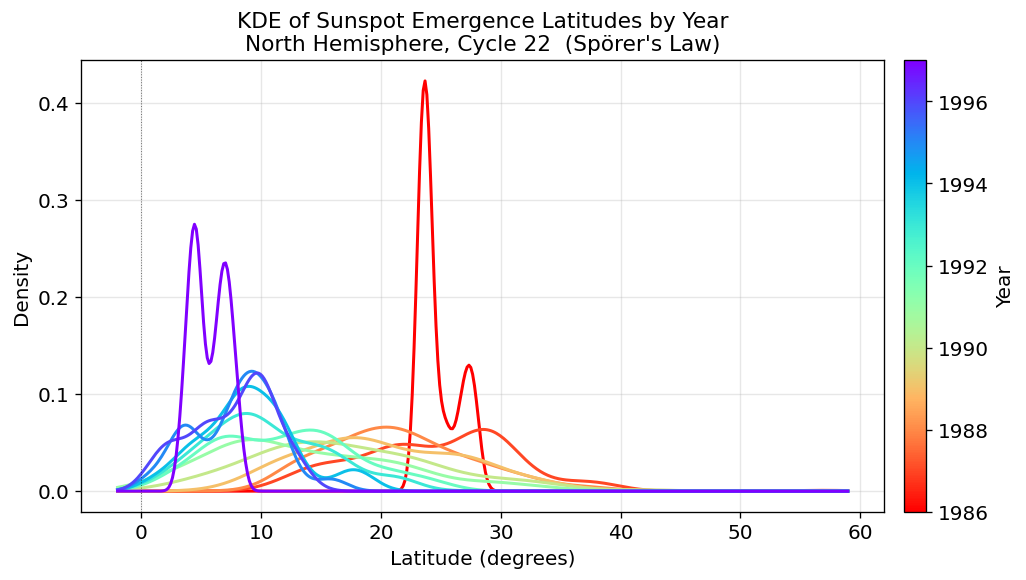

Cycle 22 (north) — yearly mean latitude:
  1986: mean=24.72°  (N=12)
  1987: mean=24.64°  (N=200)
  1988: mean=21.51°  (N=1128)
  1989: mean=20.38°  (N=1939)
  1990: mean=17.22°  (N=1571)
  1991: mean=13.77°  (N=1252)
  1992: mean=12.13°  (N=798)
  1993: mean=10.53°  (N=738)
  1994: mean=9.05°  (N=442)
  1995: mean=7.93°  (N=236)
  1996: mean=7.63°  (N=141)
  1997: mean=5.69°  (N=26)


In [34]:
# Task 8: KDE evolution through a solar cycle — Cycle 20, southern hemisphere
from scipy.stats import gaussian_kde

cycle = 22
hemi  = "north"

df_c20s = df[(df["CYCLE"] == cycle) & (df["hemisphere"] == hemi)].copy()
years   = sorted(df_c20s["year"].unique())
n_years = len(years)

# Colormap: early years → purple, late years → yellow (viridis)
cmap_kde   = plt.cm.rainbow_r
colors_kde = {yr: cmap_kde(i / (n_years - 1)) for i, yr in enumerate(years)}

# x-grid spanning the full cycle's latitude range (southern — negative values)
x_kde = np.linspace(df_c20s["latitude"].min() - 2, df_c20s["latitude"].max() + 2, 400)

fig, ax = plt.subplots(figsize=(9, 5))

for yr in years:
    lats_yr = df_c20s[df_c20s["year"] == yr]["latitude"].values
    if len(lats_yr) < 5:   # skip years with too few points to fit a KDE
        continue
    kde = gaussian_kde(lats_yr, bw_method=0.35)
    ax.plot(x_kde, kde(x_kde), color=colors_kde[yr], linewidth=1.8)

# Colorbar to show year progression
sm = plt.cm.ScalarMappable(cmap=cmap_kde,
                            norm=plt.Normalize(vmin=years[0], vmax=years[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(f"KDE of Sunspot Emergence Latitudes by Year\n"
             f"{hemi.capitalize()} Hemisphere, Cycle {cycle}  (Spörer's Law)")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Density")
ax.axvline(0, color="k", linewidth=0.6, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Print yearly mean latitudes to quantify the equatorward drift
print(f"Cycle {cycle} ({hemi}) — yearly mean latitude:")
for yr in years:
    lats_yr = df_c20s[df_c20s["year"] == yr]["latitude"].values
    print(f"  {yr}: mean={lats_yr.mean():.2f}°  (N={len(lats_yr)})")
